In [13]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import will_microshot_pipeline as wmp
import importlib

importlib.reload(wmp)


<module 'will_microshot_pipeline' from '/home/giannis/Astrovaria/will_flits_microshot_package/will_microshot_pipeline.py'>


## 1. Define the simulation setup

<!-- For FRB 20220912A-like tests,  -->
Start with a DM around 220 pc cm$^{-3}$ 
<!-- and then replace it with the exact value used by Dante/FLITS. -->


In [14]:

instrument = wmp.InstrumentConfig(
    nfreq=128,
    freq_low_mhz=1100.0,
    freq_high_mhz=1800.0,
    tsamp_ms=0.016,      
    duration_ms=12.0,   
    dm=220.0,
    noise_std=1.0,
    peak_snr=30.0,
)

instrument


InstrumentConfig(nfreq=128, freq_low_mhz=1100.0, freq_high_mhz=1800.0, tsamp_ms=0.016, duration_ms=12.0, dm=220.0, noise_std=1.0, peak_snr=30.0)


## 2. Simulate one burst with WILL


In [15]:

forest = wmp.MicroshotForestConfig(
    n_peaks=18,
    shot_sigma_ms=0.080,
    envelope_sigma_ms=1.2,
    complexity_mode='clustered',
    freq_sigma_mhz=180.0,
    drift_mhz_per_ms=-40.0,
    nscint=2,
    seed=7,
)

burst = wmp.simulate_microshot_dynamic_spectrum(
    forest=forest,
    instrument=instrument,
    prefer_will=True,
    will_method='twodim',
    burst_id='example_clustered_n18',
)

print('dynamic_spectrum shape =', burst.dynamic_spectrum.shape)
print('microshot times [ms] =', np.round(burst.shot_times_ms, 3))


dynamic_spectrum shape = (30289, 128)
microshot times [ms] = [4.533 4.641 4.658 4.832 4.891 5.591 5.696 5.8   5.815 5.951 6.028 6.06
 6.08  6.242 6.348 6.352 6.392 6.509]


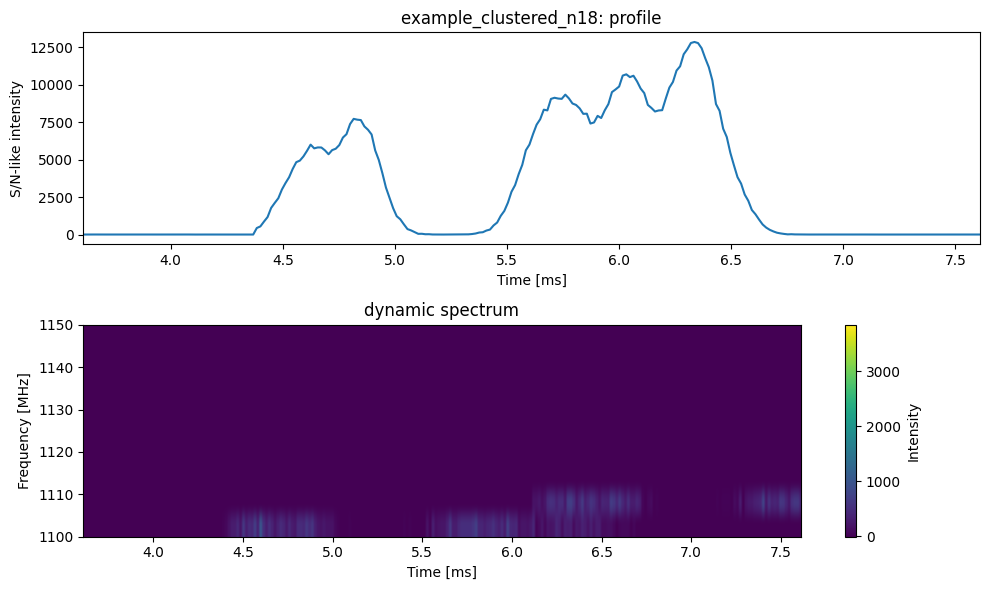

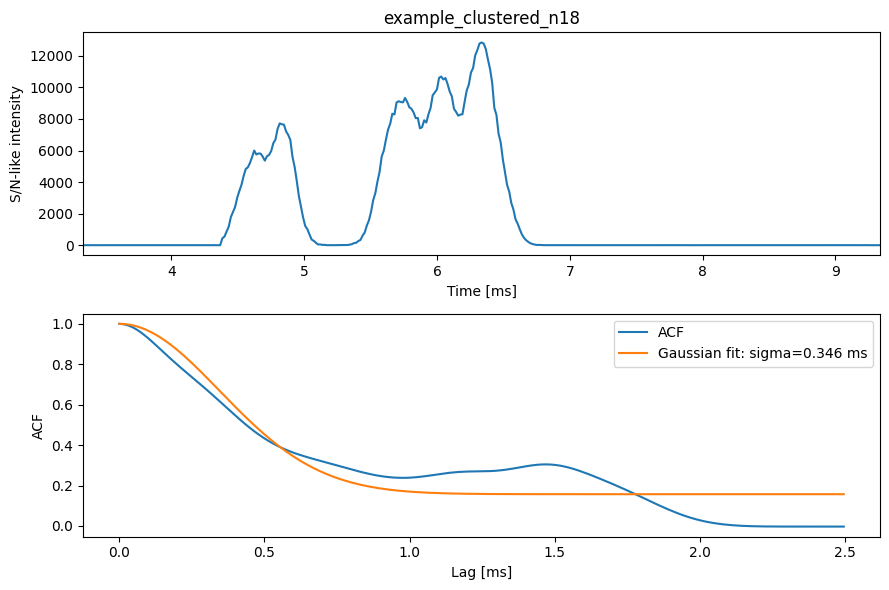

In [16]:

wmp.plot_burst_summary(burst, zoom_ms=2) # Change zoom_ms if you want to zoom around the burst
plt.show()

wmp.plot_profile_acf(burst.profile, tsamp_ms=instrument.tsamp_ms, title=burst.burst_id, zoom_ms=3) # Change zoom_ms if you want to zoom around the peak
plt.show()



## 3. Generate a bank: same microshot width, different complexity

The individual microshot width stays fixed at `shot_sigma_ms=0.080`


In [17]:

bursts = wmp.make_microshot_bank(
    n_peaks_grid=(3, 6, 12, 24, 36),
    complexity_modes=('sparse', 'moderate', 'dense', 'clustered', 'quasiperiodic'),
    n_realizations=6,
    instrument=instrument,
    shot_sigma_ms=0.080,
    envelope_sigma_ms=1.2,
    prefer_will=True,
    will_method='twodim',
    seed=2026,
)

len(bursts) #, bursts[0].used_will


150


## 4. Measure ACF timescale and complexity metrics

The matching variable is `acf_sigma_ms` or `acf_fwhm_ms`. The complexity variables are peak count, separation statistics, entropy, Gini coefficient, and the residual structure left after fitting a simple Gaussian ACF.


In [18]:

metrics = wmp.analyse_burst_bank(
    bursts,
    peak_sigma_threshold=5.0,
    min_peak_distance_ms=0.040,
    acf_fit_max_lag_ms=2.5,
)

metrics


,burst_id,input_n_peaks,input_shot_sigma_ms,acf_sigma_ms,acf_fwhm_ms,acf_resid_rms,peak_count,peak_rate_per_ms,t90_ms,median_peak_width_ms,...,psd_slope,peak_threshold_sigma,min_peak_distance_ms,complexity_mode,used_will,will_method,duration_ms,tsamp_ms,dm,nfreq
0,sparse_n03_r00,3,0.08,0.110062,0.259176,0.046430,5,1.329787,3.760,0.187157,...,-3.407982,5.0,0.04,sparse,True,twodim,12.0,0.016,220.0,128
1,sparse_n03_r01,3,0.08,0.104393,0.245826,0.094189,5,1.407658,3.552,0.186998,...,-3.253018,5.0,0.04,sparse,True,twodim,12.0,0.016,220.0,128
2,sparse_n03_r02,3,0.08,0.112904,0.265868,0.000352,5,0.666311,7.504,0.186232,...,-2.920414,5.0,0.04,sparse,True,twodim,12.0,0.016,220.0,128
3,sparse_n03_r03,3,0.08,0.134263,0.316166,0.026739,5,1.120072,4.464,0.137781,...,-2.967139,5.0,0.04,sparse,True,twodim,12.0,0.016,220.0,128
4,sparse_n03_r04,3,0.08,0.106487,0.250758,0.097281,5,0.927300,5.392,0.185636,...,-2.999985,5.0,0.04,sparse,True,twodim,12.0,0.016,220.0,128
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,quasiperiodic_n36_r01,36,0.08,0.881889,2.076689,0.128252,78,9.027778,8.640,0.015111,...,-2.251296,5.0,0.04,quasiperiodic,True,twodim,12.0,0.016,220.0,128
146,quasiperiodic_n36_r02,36,0.08,0.183647,0.432456,0.077917,89,10.095281,8.816,0.012733,...,-2.193895,5.0,0.04,quasiperiodic,True,twodim,12.0,0.016,220.0,128
147,quasiperiodic_n36_r03,36,0.08,0.144861,0.341121,0.114759,77,8.879151,8.672,0.013485,...,-2.285122,5.0,0.04,quasiperiodic,True,twodim,12.0,0.016,220.0,128
148,quasiperiodic_n36_r04,36,0.08,0.670535,1.578990,0.103906,100,11.301989,8.848,0.013124,...,-2.090712,5.0,0.04,quasiperiodic,True,twodim,12.0,0.016,220.0,128


### The most important parameters for 15 bursts, sorted by `acf_sigma_ms` value

In [19]:
cols = [
    'burst_id', 'complexity_mode', 'input_n_peaks',
    'acf_sigma_ms', 'acf_fwhm_ms', 'peak_count', 'peak_rate_per_ms',
    'median_sep_ms', 'sep_cv', 'amplitude_entropy',
    'amplitude_gini', 'acf_resid_rms'
]
metrics[cols].sort_values('acf_sigma_ms').head(15)


,burst_id,complexity_mode,input_n_peaks,acf_sigma_ms,acf_fwhm_ms,peak_count,peak_rate_per_ms,median_sep_ms,sep_cv,amplitude_entropy,amplitude_gini,acf_resid_rms
139,quasiperiodic_n24_r01,quasiperiodic,24,0.073320,0.172655,52,5.824373,0.192,0.789018,0.950319,0.318795,0.079118
138,quasiperiodic_n24_r00,quasiperiodic,24,0.074060,0.174399,45,4.995560,0.232,0.680189,0.906284,0.409301,0.060813
143,quasiperiodic_n24_r05,quasiperiodic,24,0.074810,0.176163,55,6.272810,0.176,0.631955,0.907237,0.454273,0.056268
141,quasiperiodic_n24_r03,quasiperiodic,24,0.075525,0.177848,45,5.276735,0.248,0.650591,0.922288,0.390592,0.075690
140,quasiperiodic_n24_r02,quasiperiodic,24,0.075825,0.178554,56,5.993151,0.192,0.748827,0.901790,0.458290,0.065495
142,quasiperiodic_n24_r04,quasiperiodic,24,0.077232,0.181869,54,6.181319,0.176,0.804247,0.929304,0.372871,0.046035
136,quasiperiodic_n12_r04,quasiperiodic,12,0.085734,0.201887,29,2.995868,0.312,0.731581,0.791635,0.573191,0.109432
135,quasiperiodic_n12_r03,quasiperiodic,12,0.086205,0.202998,35,4.088785,0.288,0.541116,0.785481,0.620256,0.151044
137,quasiperiodic_n12_r05,quasiperiodic,12,0.086538,0.203781,30,3.114618,0.304,0.576529,0.788648,0.580346,0.118178
132,quasiperiodic_n12_r00,quasiperiodic,12,0.087198,0.205336,38,4.087780,0.256,0.781617,0.752563,0.662922,0.079494



## 5. Select bursts with similar measured timescale but different complexity

`acf_sigma_ms` values are around 15% difference from a specific value, sorted by `peak_count`


In [20]:

selected = wmp.select_similar_timescale_different_complexity(
    metrics,
    tau_col='acf_sigma_ms',
    tolerance_fraction=0.15,
    min_group_size=4,
)

selected[cols].sort_values('peak_count')


,burst_id,complexity_mode,input_n_peaks,acf_sigma_ms,acf_fwhm_ms,peak_count,peak_rate_per_ms,median_sep_ms,sep_cv,amplitude_entropy,amplitude_gini,acf_resid_rms
4,moderate_n03_r00,moderate,3,0.154357,0.363482,3,1.030220,1.440,0.777778,0.614402,0.399453,0.053084
11,clustered_n03_r01,clustered,3,0.128562,0.302741,3,2.717391,0.440,0.309091,0.389646,0.565067,0.041909
13,clustered_n03_r04,clustered,3,0.141810,0.333938,4,1.633987,0.176,1.219777,0.987225,0.098554,0.129739
1,sparse_n03_r03,sparse,3,0.134263,0.316166,5,1.120072,0.224,1.410589,0.762933,0.436531,0.026739
12,clustered_n06_r02,clustered,6,0.153015,0.360322,5,2.297794,0.416,0.826045,0.980651,0.135098,0.128008
9,sparse_n06_r01,sparse,6,0.134975,0.317842,8,1.048218,0.304,1.907321,0.694838,0.574218,0.104392
6,dense_n06_r03,dense,6,0.136247,0.320838,8,2.824859,0.304,0.722935,0.817851,0.422026,0.062901
21,clustered_n06_r00,clustered,6,0.121990,0.287266,8,4.310345,0.160,1.217474,0.698677,0.558248,0.120726
15,moderate_n06_r02,moderate,6,0.135517,0.319119,9,3.429878,0.328,0.662401,0.722941,0.568949,0.122527
2,sparse_n06_r00,sparse,6,0.122738,0.289025,10,1.225490,0.320,1.543648,0.719055,0.573739,0.021295


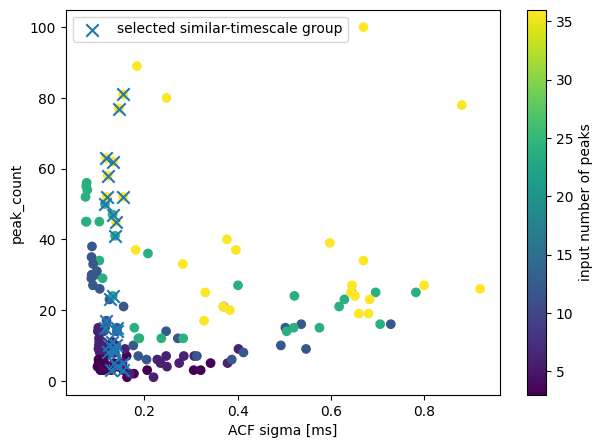

In [21]:

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(
    metrics['acf_sigma_ms'],
    metrics['peak_count'],
    c=metrics['input_n_peaks'],
)
ax.scatter(
    selected['acf_sigma_ms'],
    selected['peak_count'],
    marker='x',
    s=80,
    label='selected similar-timescale group',
)
ax.set_xlabel('ACF sigma [ms]')
ax.set_ylabel('peak_count')
ax.legend()
fig.colorbar(sc, ax=ax, label='input number of peaks')
plt.show()


### Plot the lowest and highest `peak_count` 


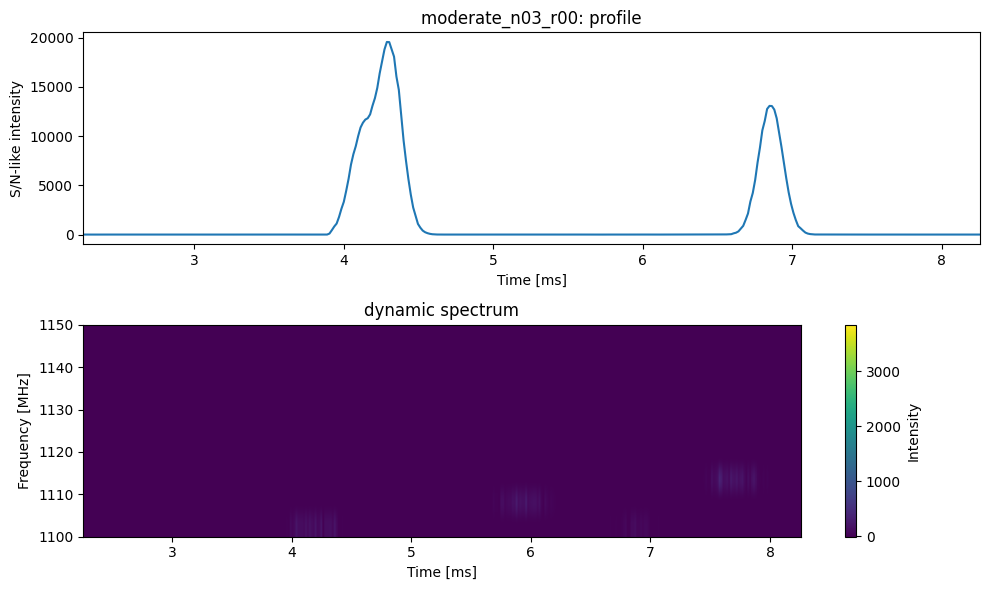

                                 30
burst_id           moderate_n03_r00
complexity_mode            moderate
input_n_peaks                     3
acf_sigma_ms               0.154357
acf_fwhm_ms                0.363482
peak_count                        3
peak_rate_per_ms            1.03022
median_sep_ms                  1.44
sep_cv                     0.777778
amplitude_entropy          0.614402
amplitude_gini             0.399453
acf_resid_rms              0.053084


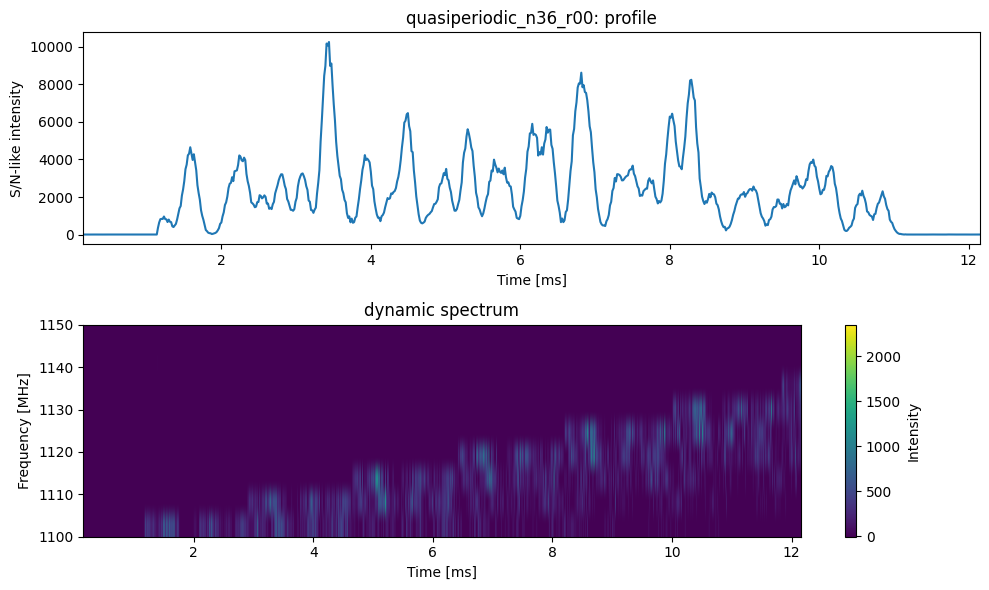

                                     144
burst_id           quasiperiodic_n36_r00
complexity_mode            quasiperiodic
input_n_peaks                         36
acf_sigma_ms                    0.153769
acf_fwhm_ms                     0.362097
peak_count                            81
peak_rate_per_ms               10.004941
median_sep_ms                      0.064
sep_cv                          0.910138
amplitude_entropy                0.95506
amplitude_gini                  0.343512
acf_resid_rms                   0.130787


In [25]:
if len(selected) >= 2:
    low_id = selected.sort_values('peak_count').iloc[0]['burst_id']
    high_id = selected.sort_values('peak_count').iloc[-1]['burst_id']
    by_id = {b.burst_id: b for b in bursts}
    
    wmp.plot_burst_summary(by_id[low_id], zoom_ms = 3)
    plt.show()
    print(metrics.loc[metrics['burst_id'] == low_id, cols].T)

    wmp.plot_burst_summary(by_id[high_id], zoom_ms = 6)
    plt.show()
    print(metrics.loc[metrics['burst_id'] == high_id, cols].T)



## 6. Save results

The `.npz` files contain `dynamic_spectrum`, `profile`, `chan_freqs_mhz`, `tsamp_ms`, and `dm`.


In [26]:

from pathlib import Path

outdir = Path('will_microshot_outputs')
outdir.mkdir(exist_ok=True)
(outdir / 'npz').mkdir(exist_ok=True)

metrics.to_csv(outdir / 'will_bank_metrics.csv', index=False)
selected.to_csv(outdir / 'will_bank_selected_similar_timescale.csv', index=False)

selected_ids = set(selected['burst_id'])
for b in bursts:
    if b.burst_id in selected_ids:
        wmp.save_burst_npz(b, outdir / 'npz' / f'{b.burst_id}.npz')

print('saved to', outdir)


saved to will_microshot_outputs
